### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [4]:
from imblearn.over_sampling import RandomOverSampler

### Step 2: Load Data

In [53]:
train = pd.read_csv('./data/TitanicSurvival/train.csv')
test = pd.read_csv('./data/TitanicSurvival/test.csv')

In [6]:
print('train shape is:', train.shape, 'test shape is:', test.shape)

train shape is: (891, 12) test shape is: (418, 11)


In [7]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 3: Exploaring Data

Basic Info

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [8]:
feature_info = pd.DataFrame(
    {'null': train.isnull().sum(), 'null(%)': 100 * train.isnull().sum()/train.shape[0], 'unique': train.nunique(), 'type': train.dtypes}
)

In [9]:
feature_info

,null,null(%),unique,type
PassengerId,0,0.000000,891,int64
Survived,0,0.000000,2,int64
Pclass,0,0.000000,3,int64
Name,0,0.000000,891,object
Sex,0,0.000000,2,object
Age,177,19.865320,88,float64
SibSp,0,0.000000,7,int64
Parch,0,0.000000,7,int64
Ticket,0,0.000000,681,object
Fare,0,0.000000,248,float64


Target Distribution

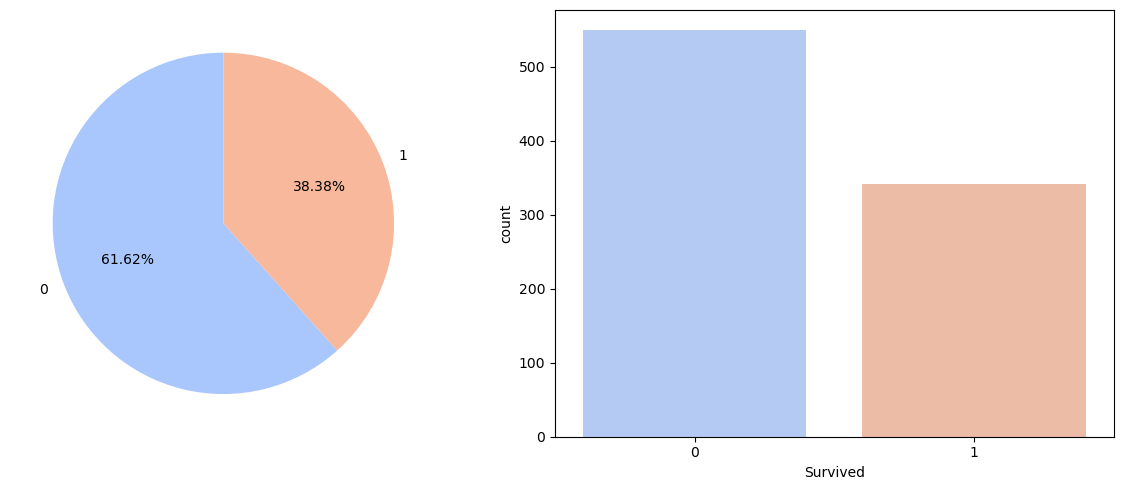

In [10]:
temp = train['Survived'].value_counts()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    startangle=90,
    colors=sns.color_palette('coolwarm', 2)
)
plt.subplot(1, 2, 2)
sns.countplot(x='Survived', data=train, palette='coolwarm')
plt.tight_layout()

Discrete Distribution

In [11]:
discrete_cols = feature_info[
    (feature_info['unique'] <= 4) & 
    ((feature_info['type'] == 'int64') | (feature_info['type'] == 'object'))
    ].index.to_list()
discrete_cols.remove('Survived')

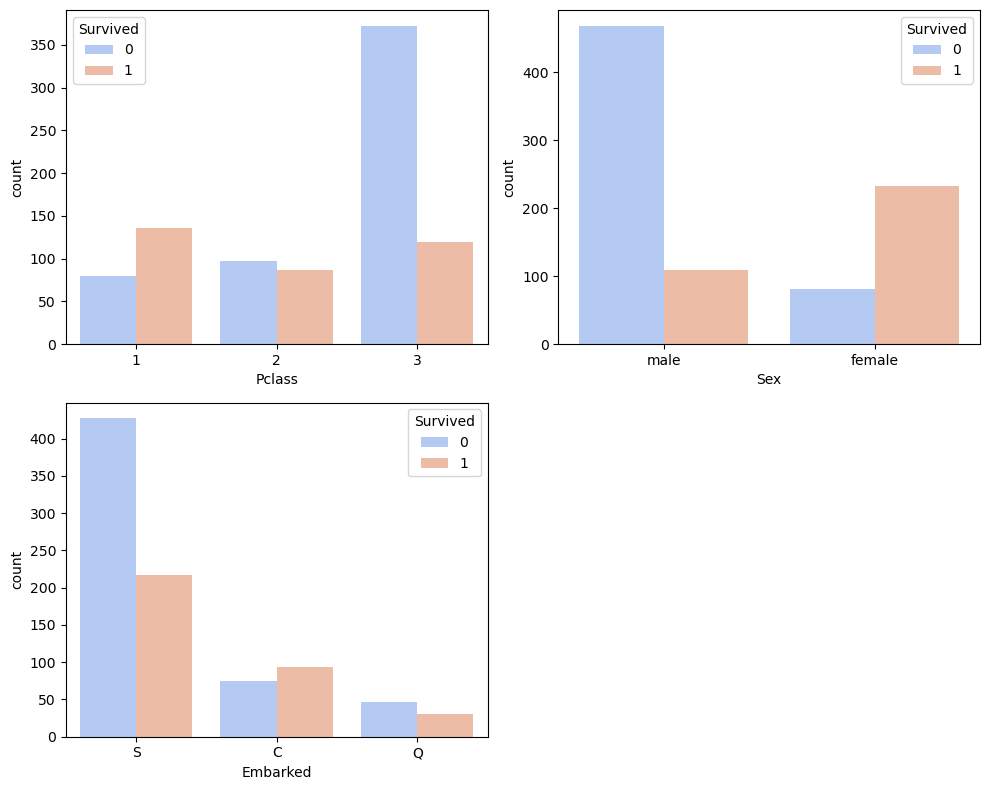

In [12]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(discrete_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, hue='Survived', data=train, palette='coolwarm')
plt.tight_layout()

Float Distribution

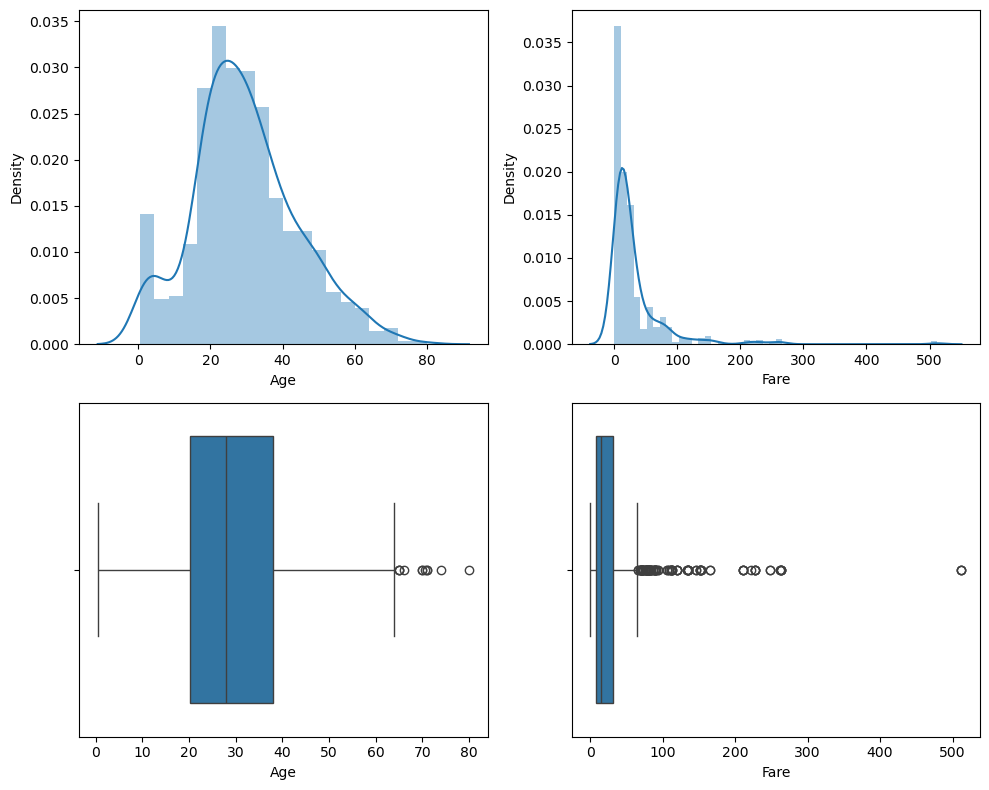

In [13]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
sns.distplot(train['Age'])
plt.subplot(2, 2, 2)
sns.distplot(train['Fare'])
plt.subplot(2, 2, 3)
sns.boxplot(train['Age'], orient='h')
plt.subplot(2, 2, 4)
sns.boxplot(train['Fare'], orient='h')
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [54]:
train.drop(['Cabin', 'Ticket', 'PassengerId'], axis=1, inplace=True)
test.drop(['Cabin', 'Ticket'], axis=1, inplace=True)

In [55]:
train = train.fillna({'Embarked': 'S'})
test = test.fillna({'Embarked': 'S'})

Deal Age

In [56]:
bins = [0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Senior']

In [57]:
train['AgeGroup'] = pd.cut(train['Age'], bins, labels=labels)
test['AgeGroup'] = pd.cut(test['Age'], bins, labels=labels)

In [58]:
train.drop(['Age'], axis=1, inplace=True)
test.drop(['Age'], axis=1, inplace=True)

In [59]:
mapping = {
    'Rare': ['Lady', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'],
    'Royal': ['Countess', 'Sir'],
    'Miss': ['Mlle', 'Ms'],
    'Mrs': ['Mme']
}

In [60]:
for df in [train, test]:
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    for key in mapping.keys():
        df['Title'] = df['Title'].replace(mapping[key], key)

In [61]:
train.drop(['Name'], axis=1, inplace=True)
test.drop(['Name'], axis=1, inplace=True)

In [62]:
for title in train['Title'].unique():
    fillValue = train[train['Title'] == title]['AgeGroup'].mode()[0]
    mask = (train['Title'] == title) & (train['AgeGroup'].isna())
    train.loc[mask, 'AgeGroup'] = fillValue

In [63]:
for title in test['Title'].unique():
    fillValue = test[test['Title'] == title]['AgeGroup'].mode()[0]
    mask = (test['Title'] == title) & (test['AgeGroup'].isna())
    test.loc[mask, 'AgeGroup'] = fillValue

Deal Fare

In [64]:
fare_mean = train.groupby('Pclass')['Fare'].mean()

In [65]:
mask = test['Fare'].isna()

In [66]:
test.loc[mask, 'Fare'] = test.loc[mask, 'Pclass'].map(fare_mean)

In [67]:
train['FareBand'] = pd.qcut(train['Fare'], 4, labels=[0, 1, 2, 3])
test['FareBand'] = pd.qcut(test['Fare'], 4, labels=[0, 1, 2, 3])

In [68]:
train.drop('Fare', axis=1, inplace=True)
test.drop('Fare', axis=1, inplace=True)

Feature Encoding

In [69]:
obj_cols = train.select_dtypes([np.object_, pd.CategoricalDtype]).columns.to_list()

In [70]:
for col in obj_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

Heat Map

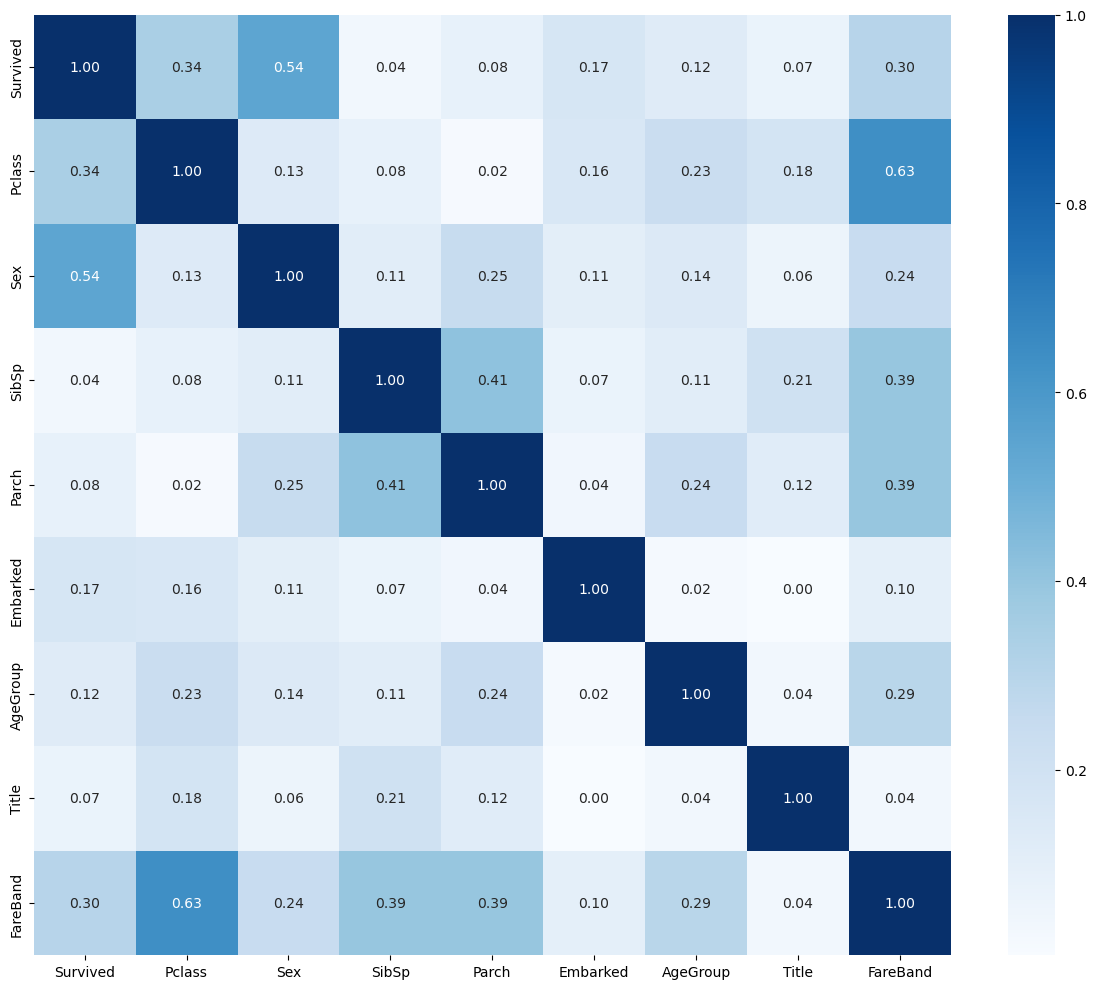

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    train.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

Select Feature

In [71]:
features = train.drop('Survived', axis=1)
target = train['Survived']

Split Data

In [29]:
X_train, X_value, y_train, y_value = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Balance Data

In [30]:
ros = RandomOverSampler(sampling_strategy='minority', random_state=42)

In [31]:
X_train, y_train = ros.fit_resample(X_train, y_train)

Normalization

In [32]:
scaler = StandardScaler()

In [33]:
X_train = scaler.fit_transform(X_train)
X_value = scaler.transform(X_value)

### Step 6: Model Development

Building Model

In [43]:
model = RandomForestClassifier()

Training Model

In [44]:
score = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    error_score='raise'
)

In [47]:
print(f'Accuracy Scores: {list(map(lambda x: round(x, 3), score))}')
print(f'Accuracy: {score.mean():.3f}')

Accuracy Scores: [0.809, 0.826, 0.876, 0.87, 0.842]
Accuracy: 0.845


In [48]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Testing Model

In [49]:
y_pred = model.predict(X_value)

Evaluating Model

In [50]:
acc_randomforest = round(metrics.accuracy_score(y_pred, y_value) * 100, 2)
print(acc_randomforest)

82.68


Prediction Model

In [74]:
ids = test['PassengerId']

In [75]:
predictions = model.predict(test.drop(['PassengerId'], axis=1))

In [76]:
output = pd.DataFrame({'PassengerId': ids, 'Survived': predictions})

In [77]:
output.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
